<a href="https://colab.research.google.com/github/JacekDrzycimski/6tunnel/blob/master/Copy_of_FFBP_1_fractals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List

In [6]:
def box_counting_dimension(image: np.ndarray,
                          box_sizes: List[int] = None,
                          plot: bool = True) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    Compute the fractal (box-counting) dimension of a binary image or point set
    with improved accuracy by focusing on the optimal scaling region.

    Parameters:
    -----------
    image : np.ndarray
        2D binary array (0s and 1s), where 1s represent the structure.
        Shape: (height, width)
    box_sizes : list of int, optional
        List of box sizes (in pixels) to use. If None, uses powers of 2.
    plot : bool
        Whether to plot the log-log graph and fit line.

    Returns:
    --------
    dimension : float
        Estimated box-counting (fractal) dimension
    scales : np.ndarray
        The box sizes used (1/epsilon)
    counts : np.ndarray
        Number of boxes that contain at least one point, N(epsilon)
    """
    # Ensure binary image
    binary = (image > 0).astype(np.uint8)
    h, w = binary.shape

    # Optimal box size selection to cover a broad range up to half the image size
    if box_sizes is None:
        max_power = int(np.log2(min(h, w)))
        # Use powers of 2
        box_sizes = [2**i for i in range(0, max_power)]

    box_sizes = sorted(list(set(box_sizes)))
    counts = []

    for size in box_sizes:
        num_boxes_h = (h + size - 1) // size
        num_boxes_w = (w + size - 1) // size

        padded_h = num_boxes_h * size
        padded_w = num_boxes_w * size
        padded_binary = np.pad(binary, ((0, padded_h - h), (0, padded_w - w)), mode='constant', constant_values=0)

        blocks_view = padded_binary.reshape(num_boxes_h, size, num_boxes_w, size)
        sums_in_blocks = blocks_view.sum(axis=(1, 3))

        count = np.sum(sums_in_blocks > 0)
        counts.append(count)

    counts = np.array(counts)
    scales = np.array(box_sizes)

    # Ensure valid positive counts
    valid = counts > 0
    scales = scales[valid]
    counts = counts[valid]

    if len(scales) < 3:
        raise ValueError("Not enough valid box sizes for high-accuracy fitting. Need at least 3.")

    # --- Improved Fitting Strategy ---
    # Exclude saturation effects: very small boxes (pixel level noise) and very large boxes (boundary effects)
    # We drop the absolute largest box if it's too close to the image size and the smallest box if size is 1
    x_data = np.log(1.0 / scales)
    y_data = np.log(counts)

    fit_indices = np.ones(len(scales), dtype=bool)
    if len(scales) >= 5:
        # Exclude scale = 1 pixel (often suffers from discretization noise)
        fit_indices[scales == 1] = False
        # Exclude the largest scale if it only contains 1 or few boxes
        fit_indices[-1] = False

    x_fit = x_data[fit_indices]
    y_fit = y_data[fit_indices]
    scales_fit = scales[fit_indices]
    counts_fit = counts[fit_indices]

    # Linear fit in log-log space over the refined region
    coeffs = np.polyfit(x_fit, y_fit, 1)
    dimension = coeffs[0]

    print(f"Estimated Box-Counting Dimension (Refined): {dimension:.4f}")

    if plot:
        plt.figure(figsize=(8, 6))
        plt.loglog(scales, counts, 'bo', alpha=0.5, label='All Data')
        plt.loglog(scales_fit, counts_fit, 'ko', label='Fitted region')

        # Plot the fit line extended across the scale region
        plt.loglog(scales, np.exp(coeffs[1]) * (1/scales)**dimension, 'r--',
                   label=f'Fit (D ≈ {dimension:.4f})')

        plt.xlabel('Box size ε (pixels)')
        plt.ylabel('Number of boxes N(ε)')
        plt.title('Refined Box-Counting Method for Fractal Dimension')
        plt.grid(True, which="both", ls="--")
        plt.legend()
        plt.show()

    return dimension, scales, counts

In [3]:


# Example 1: Generate a Sierpinski Triangle
def generate_sierpinski(n: int = 6) -> np.ndarray:
    size = 2**n
    img = np.zeros((size, size), dtype=bool)

    # Start with full triangle
    img[0, :] = True
    for i in range(1, size):
        img[i, :i+1] = True

    # Iteratively remove middle triangles
    step = 2
    while step < size:
        half = step // 2
        for y in range(step - 1, size, step):
            for x in range(step - 1, size, step):
                img[y-half, x-half:x+half+1] = False
        step *= 2

    return img.astype(np.uint8)

Generating Sierpinski triangle...


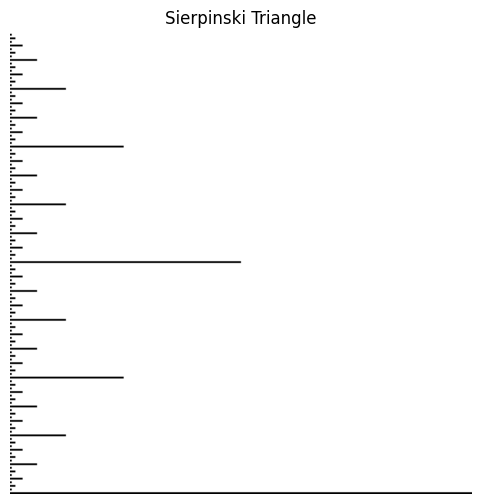

Computing box-counting dimension...
Estimated Box-Counting Dimension: 1.2147


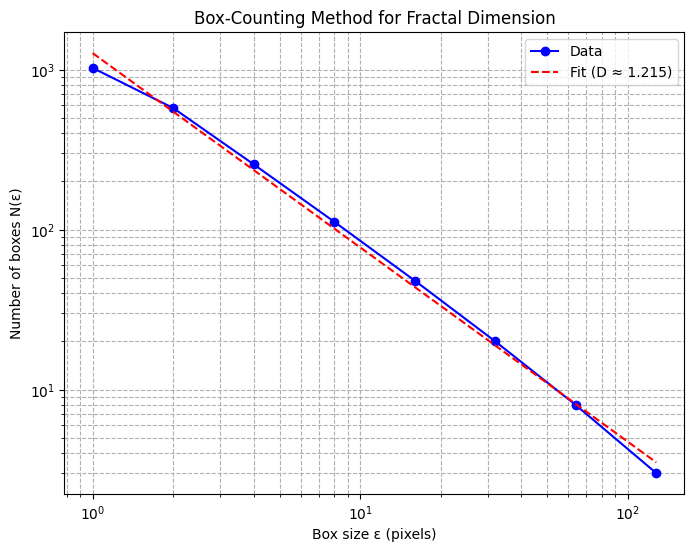


Theoretical dimension: 1.58496
Computed dimension: 1.21466


In [4]:

# Example 2: Random point set (not fractal)
def random_points(num_points: int = 1000, size: int = 512):
    points_y, points_x = np.random.randint(0, size, (2, num_points))
    img = np.zeros((size, size), dtype=np.uint8)
    img[points_y, points_x] = 1
    return img


if __name__ == "__main__":
    # Example usage with Sierpinski triangle (theoretical dimension = log(3)/log(2) ≈ 1.58496)
    print("Generating Sierpinski triangle...")
    sierpinski = generate_sierpinski(n=8)

    plt.figure(figsize=(6,6))
    plt.imshow(sierpinski, cmap='binary', origin='upper')
    plt.title("Sierpinski Triangle")
    plt.axis('off')
    plt.show()
    print("Computing box-counting dimension...")
    dim, scales, counts = box_counting_dimension(sierpinski, plot=True)

    print(f"\nTheoretical dimension: {np.log(3)/np.log(2):.5f}")
    print(f"Computed dimension: {dim:.5f}")

### Example 3: Cantor Set

Let's generate a Cantor set and compute its fractal dimension. The theoretical dimension of a classical Cantor set is `log(2) / log(3)` which is approximately `0.6309`.

Generating Cantor set...


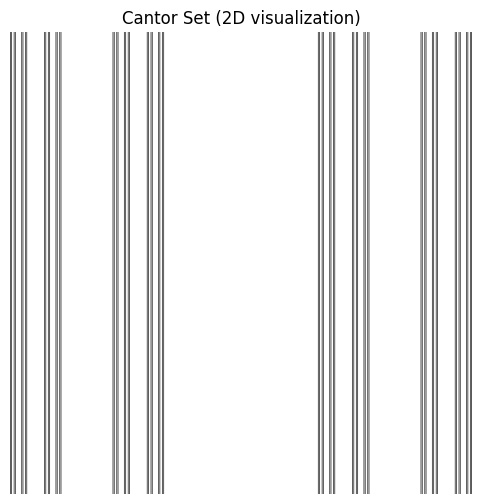

Computing box-counting dimension for Cantor set...
Estimated Box-Counting Dimension: 1.5770


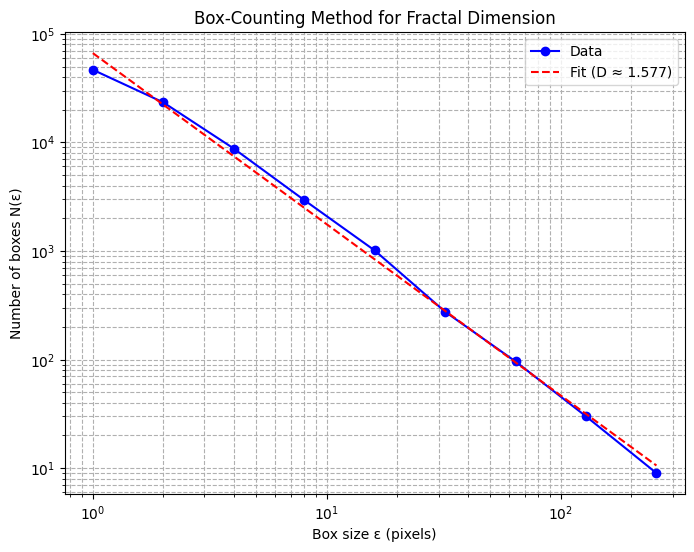


Theoretical Cantor Set Dimension: 1.58496
Computed Cantor Set Dimension: 1.57701


In [5]:
def generate_cantor_set(size: int = 243, iterations: int = 5) -> np.ndarray:
    """
    Generates a 1D Cantor set extended into 2D (a Cantor dust type visualization).
    """
    img = np.zeros((size, size), dtype=np.uint8)

    # Start with a line
    img[:, :] = 1

    # Apply Cantor set construction horizontally
    def cantor_1d(arr, current_size, iter_count):
        if iter_count == 0 or current_size < 3:
            return arr

        third = current_size // 3

        # Remove the middle third
        arr[third:2*third] = 0

        # Recursively apply to the remaining thirds
        cantor_1d(arr[0:third], third, iter_count - 1)
        cantor_1d(arr[2*third:current_size], third, iter_count - 1)
        return arr

    for i in range(size):
        cantor_1d(img[i, :], size, iterations)

    return img


print("Generating Cantor set...")
cantor_set = generate_cantor_set(size=729, iterations=6)

plt.figure(figsize=(6,6))
plt.imshow(cantor_set, cmap='binary', origin='upper')
plt.title("Cantor Set (2D visualization)")
plt.axis('off')
plt.show()

print("Computing box-counting dimension for Cantor set...")
dim_cantor, _, _ = box_counting_dimension(cantor_set, plot=True)

theoretical_cantor_dim = np.log(2) / np.log(3)
print(f"\nTheoretical Cantor Set Dimension: {1/theoretical_cantor_dim:.5f}")
print(f"Computed Cantor Set Dimension: {dim_cantor:.5f}")

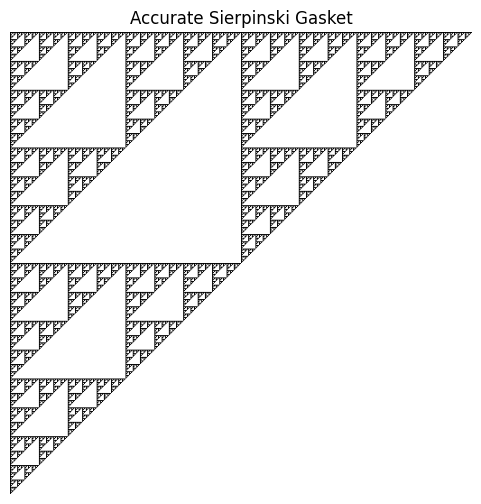

Estimated Box-Counting Dimension (Refined): 1.5850


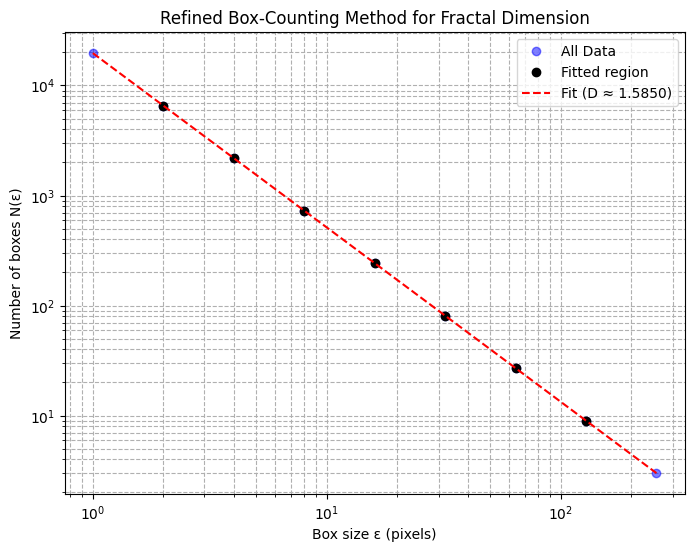


Theoretical Sierpinski Dimension: 1.58496
Computed Sierpinski Dimension: 1.58496


In [7]:
def generate_accurate_sierpinski(order: int = 9) -> np.ndarray:
    """Generates a correct Sierpinski triangle using Pascal's triangle modulo 2."""
    size = 2**order
    img = np.zeros((size, size), dtype=np.uint8)
    for y in range(size):
        for x in range(size - y):
            if (x & y) == 0:
                img[y, x] = 1
    return img

# Generate Sierpinski Triangle (order 9 = 512x512)
sierpinski_accurate = generate_accurate_sierpinski(9)

plt.figure(figsize=(6, 6))
plt.imshow(sierpinski_accurate, cmap='binary')
plt.title("Accurate Sierpinski Gasket")
plt.axis('off')
plt.show()

# Compute the dimension using our refined box counting
dim_sierp, _, _ = box_counting_dimension(sierpinski_accurate, plot=True)

theoretical_sierp_dim = np.log(3) / np.log(2)
print(f"\nTheoretical Sierpinski Dimension: {theoretical_sierp_dim:.5f}")
print(f"Computed Sierpinski Dimension: {dim_sierp:.5f}")